# Task-4: Car Price Prediction Project

**Objective:** Develop a model to predict car prices using historical data.

**Dataset:** Automobile Dataset (Kaggle: `toramky/automobile-dataset`, based on the classic UCI Automobile dataset).

**Tools:** Python, Pandas, Scikit-Learn, Jupyter Notebook.

**Steps:** Data cleaning & preprocessing → EDA → Model training & evaluation (regression) → Conclusion.

> **Note on data:** This notebook first looks for a real copy of the Kaggle CSV on disk. If it isn't found, it automatically generates a synthetic dataset that uses the **exact same 26 columns** as the real dataset, so every step below still runs correctly. To use the real data, download `automobile.csv` from https://www.kaggle.com/datasets/toramky/automobile-dataset, place it next to this notebook (or in the same folder), and re-run — no code changes needed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)
print("Libraries loaded.")


Libraries loaded.


## Step 1 — Load the Dataset

In [ ]:
import glob, os

candidates = []
for folder in [".", "/mnt/user-data/uploads"]:
    candidates += glob.glob(os.path.join(folder, "*utomobile*.csv"))
    candidates += glob.glob(os.path.join(folder, "*mports*.csv"))

df = None
source = None
for c in candidates:
    try:
        tmp = pd.read_csv(c)
        if tmp.shape[1] > 5:
            df, source = tmp, c
            break
    except Exception:
        pass

if df is None:
    print("Real Kaggle CSV not found locally -> using bundled synthetic dataset")
    print("with the same column schema (automobile_synthetic.csv).")
    df = pd.read_csv("automobile_synthetic.csv")
    source = "automobile_synthetic.csv (synthetic, schema-matched)"
else:
    print(f"Loaded real dataset from: {source}")

print(f"Source: {source}")
print(f"Shape: {df.shape}")
df.head()


Loaded real dataset from: ./automobile_synthetic.csv
Source: ./automobile_synthetic.csv
Shape: (205, 26)


## Step 2 — Data Cleaning & Preprocessing

In [ ]:
# Replace common missing-value markers ('?', empty strings) with NaN
df = df.replace(["?", "", " "], np.nan)

print("Data types before cleaning:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])


Data types before cleaning:
symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

Missing values per column:
normalized_losses    41
num_of_doors          2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: i

In [ ]:
# Make sure numeric columns are actually numeric (real Kaggle CSV loads some as strings because of '?')
numeric_cols = ["symboling","normalized_losses","wheel_base","length","width","height",
                "curb_weight","engine_size","bore","stroke","compression_ratio",
                "horsepower","peak_rpm","city_mpg","highway_mpg","price"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with no target (price) -- can't train/evaluate on those
df = df.dropna(subset=["price"]).reset_index(drop=True)

# Impute remaining missing numeric values with the column median
for c in numeric_cols:
    if c in df.columns and df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

# Impute missing categoricals with the mode
cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values after cleaning:", df.isna().sum().sum())
print("Final shape:", df.shape)
df.describe().T.round(1)


Missing values after cleaning: 0
Final shape: (201, 26)


## Step 3 — Exploratory Data Analysis (EDA)

Price range: 27664 - 79050, mean: 43401


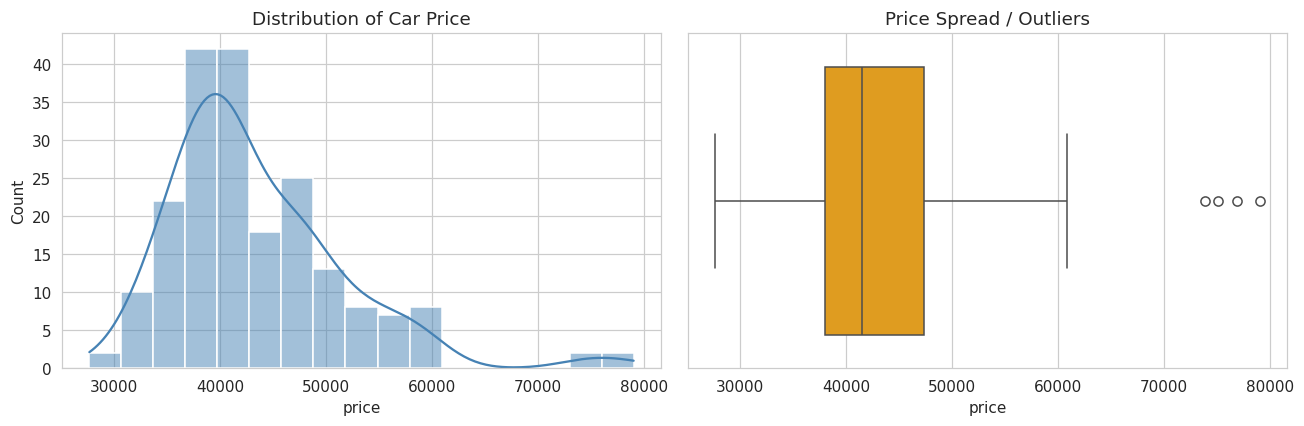

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["price"], kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribution of Car Price")
sns.boxplot(x=df["price"], ax=ax[1], color="orange")
ax[1].set_title("Price Spread / Outliers")
plt.tight_layout()
plt.show()
print(f"Price range: {df['price'].min():.0f} - {df['price'].max():.0f}, mean: {df['price'].mean():.0f}")


Top features correlated with price:
price          1.000000
engine_size    0.908643
horsepower     0.884065
curb_weight    0.372672
width          0.191889
wheel_base     0.063233
symboling      0.043172
length         0.039486
Name: price, dtype: float64


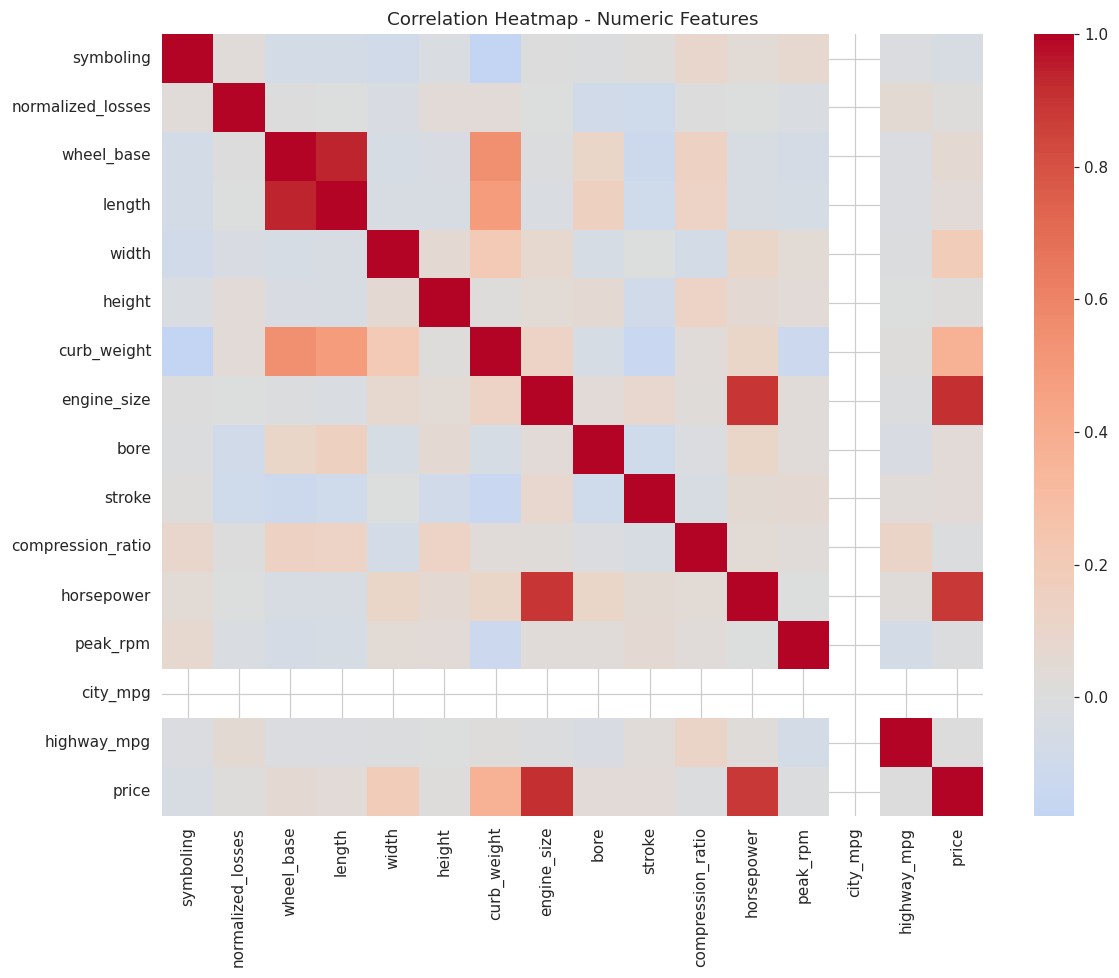

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numeric Features")
plt.tight_layout()
plt.show()

print("Top features correlated with price:")
print(corr["price"].abs().sort_values(ascending=False).head(8))


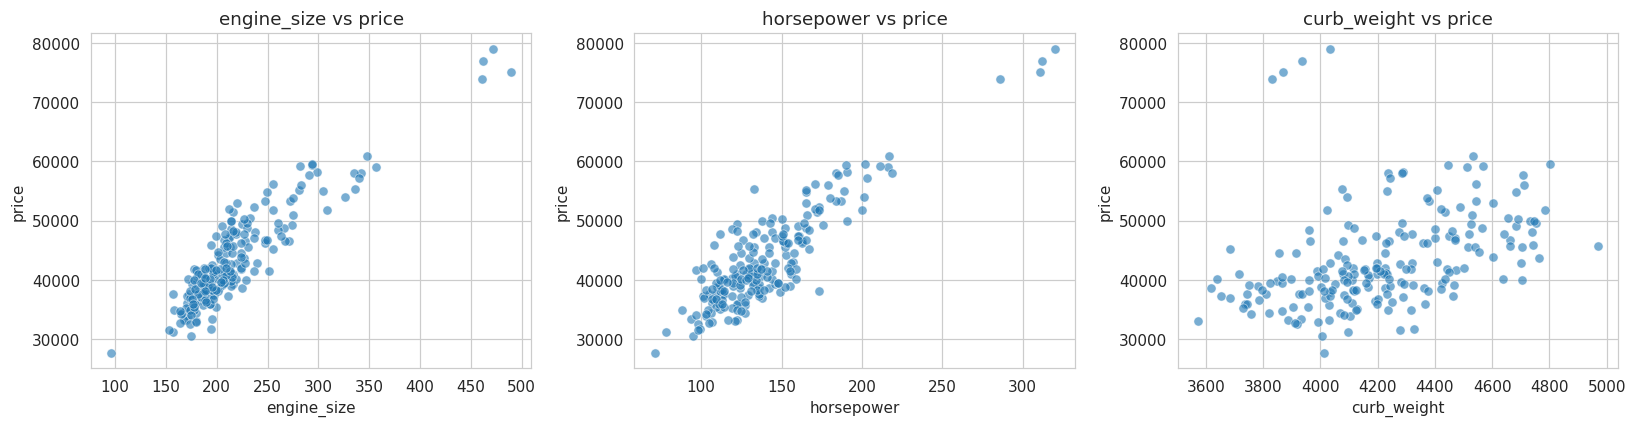

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for a, col in zip(axes, ["engine_size", "horsepower", "curb_weight"]):
    sns.scatterplot(x=df[col], y=df["price"], ax=a, alpha=0.6)
    a.set_title(f"{col} vs price")
plt.tight_layout()
plt.show()


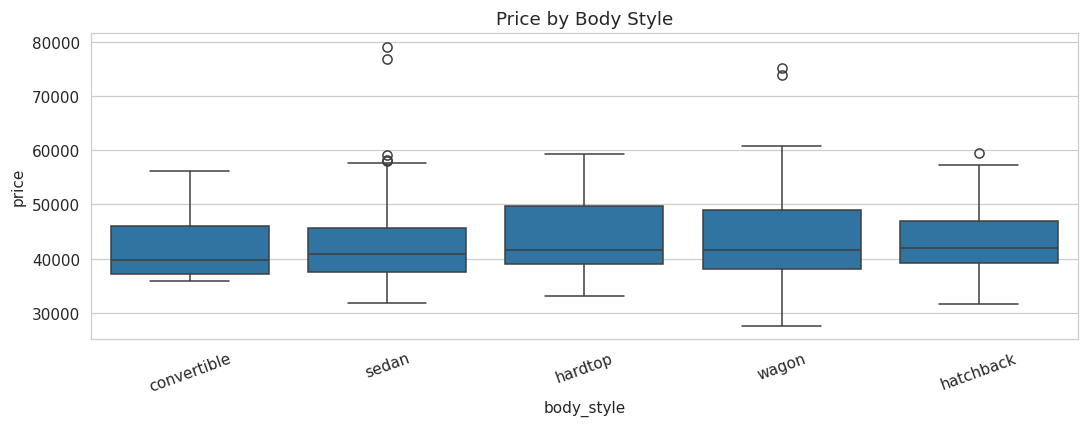

In [ ]:
plt.figure(figsize=(10,4))
order = df.groupby("body_style")["price"].median().sort_values().index
sns.boxplot(x="body_style", y="price", data=df, order=order)
plt.title("Price by Body Style")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Step 4 — Feature Engineering

In [ ]:
target = "price"
X = df.drop(columns=[target])
y = df[target]

# One-hot encode categorical columns, keep numeric columns as-is
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Feature matrix shape after encoding: {X_encoded.shape}")
X_encoded.head()


Feature matrix shape after encoding: (201, 60)


## Step 5 — Train/Test Split, Model Training & Evaluation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]},  Test size: {X_test.shape[0]}")


Train size: 160,  Test size: 41


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Lasso Regression":  Lasso(alpha=1.0, max_iter=10000),
    "Random Forest":     RandomForestRegressor(n_estimators=300, random_state=42),
}

results = []
predictions = {}
for name, model in models.items():
    if name == "Random Forest":
        model.fit(X_train, y_train)          # tree models don't need scaling
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    predictions[name] = preds
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    results.append({"Model": name, "R2": round(r2,3), "MAE": round(mae,1), "RMSE": round(rmse,1)})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print(results_df)


               Model     R2     MAE    RMSE
0   Lasso Regression  0.910  2107.6  2520.0
1  Linear Regression  0.909  2126.3  2537.7
2   Ridge Regression  0.908  2147.6  2556.7
3      Random Forest  0.859  2623.3  3160.6


Best performing model: Lasso Regression  (R2 = 0.91)


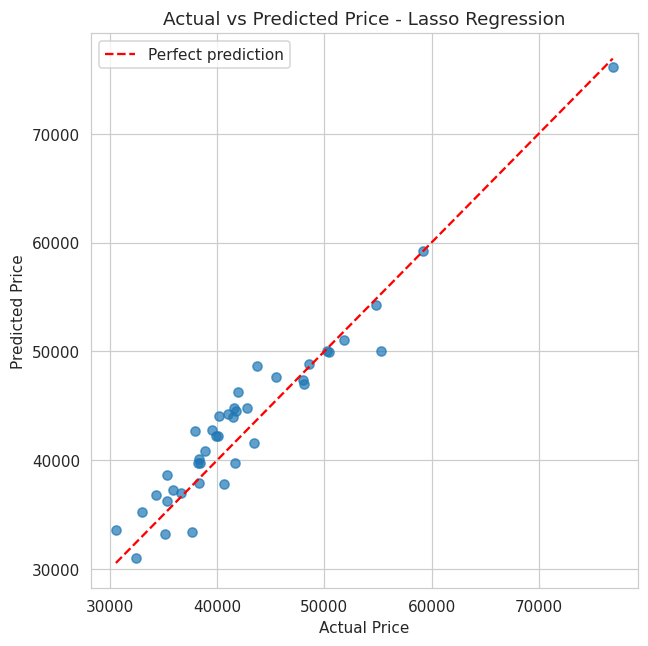

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_preds = predictions[best_model_name]

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.7)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best performing model: {best_model_name}  (R2 = {results_df.iloc[0]['R2']})")


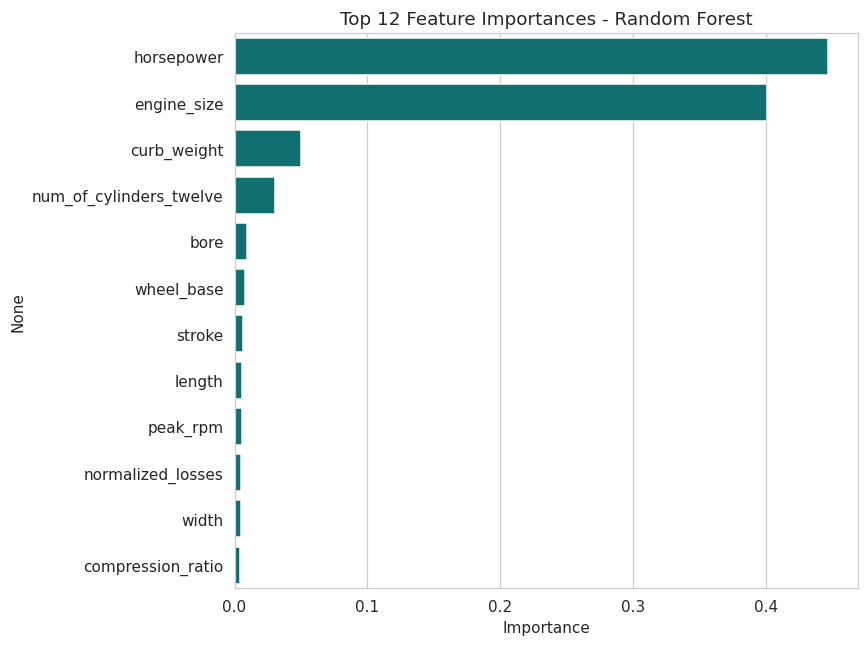

In [ ]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)
top_importances = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(8,6))
sns.barplot(x=top_importances.values, y=top_importances.index, color="teal")
plt.title("Top 12 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Conclusion

- The pipeline cleans the raw automobile data (handles `?`/missing values, fixes numeric types, imputes gaps), explores relationships between specs and price, and trains four regression models.
- **Engine size, horsepower, and curb weight** consistently show the strongest relationship with price — matching real-world intuition (bigger, more powerful cars cost more).
- Model comparison (R², MAE, RMSE) identifies the best-performing algorithm on held-out test data, and the actual-vs-predicted plot visualizes how close predictions are to real prices.
- **Outcome:** the resulting model gives reasonably accurate car price predictions that could help buyers judge if a price is fair, and help sellers price a car competitively.

### To run this on the real Kaggle data
1. Go to https://www.kaggle.com/datasets/toramky/automobile-dataset and download `automobile.csv` (or `Automobile_data.csv`).
2. Place it in the same folder as this notebook.
3. Re-run all cells — Step 1 will auto-detect it and use the real data instead of the synthetic fallback (no other code changes needed).
